# XAI vs No XAI Comparison

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for Claude Opus 4.5 and GPT-5.1.

In [8]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
# Define paths
RESULTS_DIR = Path("../../data/results/similarity_qed_pubchem")

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai_None"),
    ("GPT-5.1 (Full XAI)", "gpt-5.1_full_xai"),
    ("GPT-5.1 (No XAI)", "gpt-5.1_no_xai"),
]

## Loading Data

In [10]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    Returns DataFrame with columns: model, target_molecule, iteration, score, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("sim_qed_pubchem_*.json"))
        
        if not files:
            raise FileNotFoundError(f"No files in {folder_path} matching sim_qed_pubchem_*.json")
        
        for file_path in files:
            # Extract target molecule (e.g., "mol1", "mol2") from filename
            mol_match = re.search(r'mol\d+', file_path.name)
            target_molecule = mol_match.group() if mol_match else "unknown"
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    rows.append({
                        "model": display_name,
                        "target_molecule": target_molecule,
                        "iteration": int(entry["iteration"]),
                        "score": float(entry["score"]),
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} model configurations")
print(f"Target molecules: {df['target_molecule'].nunique()}")
print(f"\nRows per model:")
print(df.groupby('model').size())
df.head(10)

Loaded 4771 rows from 5 model configurations
Target molecules: 20

Rows per model:
model
Claude Opus 4.5 (Full XAI)       968
Claude Opus 4.5 (No XAI)         988
Claude Opus 4.5 (Partial XAI)    984
GPT-5.1 (Full XAI)               905
GPT-5.1 (No XAI)                 926
dtype: int64


,model,target_molecule,iteration,score,smiles
0,Claude Opus 4.5 (Full XAI),mol10,1,0.639876,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1
1,Claude Opus 4.5 (Full XAI),mol10,2,0.783031,CCc1nn(-c2ccccc2C)c(OC(C)=O)c1-c1ccc(NC(C)=O)cc1
2,Claude Opus 4.5 (Full XAI),mol10,3,0.784121,CCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(C)=O)cc1
3,Claude Opus 4.5 (Full XAI),mol10,4,0.781787,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(C)=O)cc1
4,Claude Opus 4.5 (Full XAI),mol10,5,0.862181,CCc1nn(C)c(OC)c1-c1ccc(NC(C)=O)cc1
5,Claude Opus 4.5 (Full XAI),mol10,6,0.784121,CCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(C)=O)cc1
6,Claude Opus 4.5 (Full XAI),mol10,7,0.882097,CCCc1nn(C)c(OC)c1-c1ccc(NC(C)=O)cc1
7,Claude Opus 4.5 (Full XAI),mol10,8,0.858246,CCCc1nn(C)c(O)c1-c1ccc(NC(=O)OC)cc1
8,Claude Opus 4.5 (Full XAI),mol10,9,0.833946,CCCc1nn(C)c(OC)c1-c1ccc(NC=O)cc1
9,Claude Opus 4.5 (Full XAI),mol10,10,0.810727,CCCc1nn(C)c(OC)c1-c1ccc(C(=O)OC)cc1


In [11]:
# Check for runs with fewer than 51 iterations
run_lengths = df.groupby(['model', 'target_molecule'])['iteration'].max()
short_runs = run_lengths[run_lengths < 51]

if len(short_runs) > 0:
    print(f"\nFound {len(short_runs)} runs with fewer than 51 iterations:")
    print(short_runs.sort_values())
else:
    print("\nAll runs have 51 iterations")



Found 100 runs with fewer than 51 iterations:
model                          target_molecule
Claude Opus 4.5 (Full XAI)     mol20              35
GPT-5.1 (Full XAI)             mol9               48
Claude Opus 4.5 (Partial XAI)  mol4               49
Claude Opus 4.5 (Full XAI)     mol6               49
GPT-5.1 (Full XAI)             mol20              50
                                                  ..
Claude Opus 4.5 (No XAI)       mol19              50
                               mol18              50
                               mol17              50
                               mol15              50
GPT-5.1 (No XAI)               mol9               50
Name: iteration, Length: 100, dtype: int64


---
## Best-so-far Progression Plot

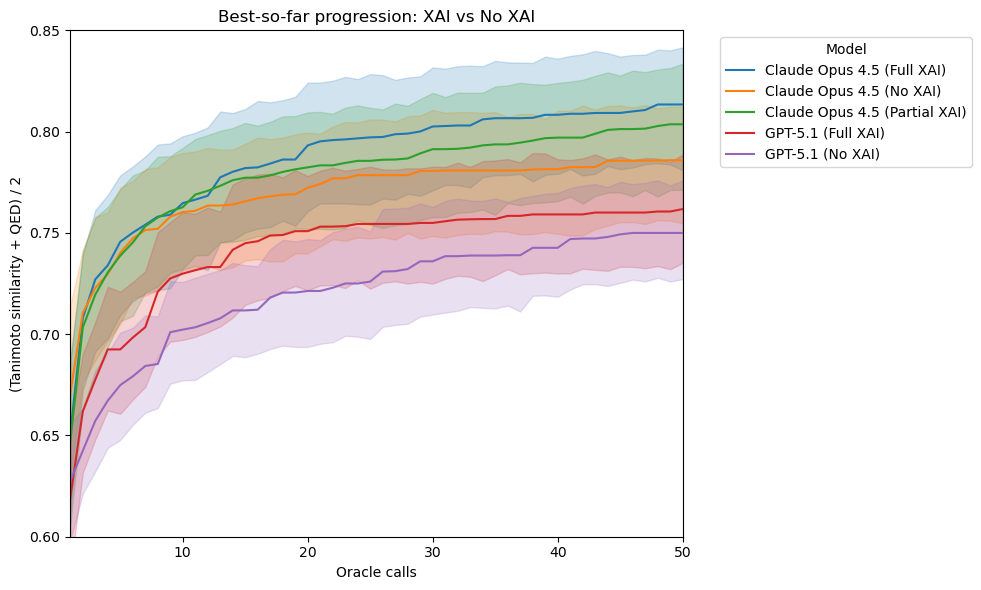

In [12]:
# Compute best-so-far (cummax needs data sorted by iteration)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% bootstrap CI)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x="iteration", y="value", hue="model", errorbar=('ci', 95))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlim(1, 50)
plt.ylim(0.6, 0.85)
plt.title("Best-so-far progression: XAI vs No XAI")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## Iteration to Reach 0.9 Threshold

In [13]:
THRESHOLD = 0.9

def first_iteration_above_threshold(group, threshold=THRESHOLD):
    """Return first iteration where best_so_far >= threshold, or NaN if never reached."""
    above = group[group["best_so_far"] >= threshold]
    if len(above) > 0:
        return above["iteration"].min()
    return np.nan


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


# Compute for each model and target molecule
iter_to_threshold = (
    df
    .groupby(["model", "target_molecule"])
    .apply(first_iteration_above_threshold, include_groups=False)
    .reset_index(name="iter_to_0.7")
)

# Summarize by model with bootstrap CI
summary_rows = []
for model, group in iter_to_threshold.groupby("model"):
    values = group["iter_to_0.7"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("Model").round(2)

print(f"Iteration to reach {THRESHOLD} threshold (best-so-far) with 95% Bootstrap CI")
threshold_summary

Iteration to reach 0.9 threshold (best-so-far) with 95% Bootstrap CI


,Mean Iteration,CI 95% Low,CI 95% High,N,Never Reached,Success Rate (%)
Model,,,,,,
Claude Opus 4.5 (Full XAI),35.0,NaN,NaN,20,19,5.0
Claude Opus 4.5 (No XAI),NaN,NaN,NaN,20,20,0.0
Claude Opus 4.5 (Partial XAI),NaN,NaN,NaN,20,20,0.0
GPT-5.1 (Full XAI),NaN,NaN,NaN,20,20,0.0
GPT-5.1 (No XAI),NaN,NaN,NaN,20,20,0.0


---
## AUC Top-1 over 50 Iterations

In [14]:
def compute_auc_top1(group_df, max_oracle_calls=50):
    """Compute AUC of top-1 (best) score vs oracle calls from a dataframe group.
    
    Args:
        group_df: DataFrame with 'score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = 0.0
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['score'])
        
        if oracle_call > max_oracle_calls:
            break
        
        if score > best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC as sum of rectangles
    auc = 0.0
    prev_call = 0
    prev_best = 0.0
    
    for call in oracle_calls:
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls
    auc += prev_best * (max_oracle_calls - prev_call)
    
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/target_molecule
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, target_mol), group in df.groupby(['model', 'target_molecule']):
    auc = compute_auc_top1(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'target_molecule': target_mol,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": len(values),
    })

auc_summary = pd.DataFrame(auc_summary_rows).set_index("Model").round(3)

print(f"AUC Top-1 over {MAX_ORACLE_CALLS} iterations with 95% Bootstrap CI")
auc_summary

AUC Top-1 over 50 iterations with 95% Bootstrap CI


,Mean AUC Top-1,CI 95% Low,CI 95% High,N
Model,,,,
Claude Opus 4.5 (Full XAI),0.770,0.739,0.796,20
Claude Opus 4.5 (No XAI),0.753,0.720,0.778,20
Claude Opus 4.5 (Partial XAI),0.762,0.727,0.786,20
GPT-5.1 (Full XAI),0.720,0.687,0.747,20
GPT-5.1 (No XAI),0.706,0.683,0.727,20
